# FIT5196 Assignment 1 (2026) 中文讲解版 Solution

## Group XXX

- Member 1: 姓名, 学号, 邮箱, Contribution
- Member 2: 姓名, 学号, 邮箱, Contribution
- Member 3: 姓名, 学号, 邮箱, Contribution
- Member 4: 姓名, 学号, 邮箱, Contribution

这份 notebook 面向补习班讲解，按照 2026 版要求重写，兼顾：

1. 可以稳定生成符合 sample output 的 CSV
2. 可以支撑 EDA 报告里的图和分析
3. 可以衔接最后的 insight 和 ML question 讲解

## 0. 2026 版本重点提醒

- 输入文件名变成了 `Group_<group_number>.xml` 和 `Group_<group_number>.json`
- 输出 CSV 的字段顺序必须和 `sample_output.csv` 一致
- 明确要求去掉 `redundant duplicate records`
- 明确要求移除 `non-Latin characters`，但拉丁字母体系的欧洲语言可以保留
- 至少要有 10 个高质量 insights 和 5 个高质量 ML questions
- 2026 版更强调 justification，不能只给图不给解释

## 1. Load, Parse and Merge Data Files

In [46]:
from __future__ import annotations

from pathlib import Path
import json
import re
from xml.etree import ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

In [47]:
# 课堂演示版：直接假设当前目录里就是这三个文件
BASE_DIR = Path.cwd()
JSON_PATH = BASE_DIR / "GroupXXX.json"
XML_PATH = BASE_DIR / "GroupXXX.xml"
OUTPUT_CSV = BASE_DIR / "GroupXXX_dataset.csv"
SAMPLE_OUTPUT_PATH = BASE_DIR / "sample_output.csv"

print("当前工作目录:", BASE_DIR)
print("JSON 文件:", JSON_PATH.name)
print("XML 文件:", XML_PATH.name)
print("输出文件:", OUTPUT_CSV.name)

assert JSON_PATH.exists(), f"找不到文件: {JSON_PATH}"
assert XML_PATH.exists(), f"找不到文件: {XML_PATH}"
assert SAMPLE_OUTPUT_PATH.exists(), f"找不到文件: {SAMPLE_OUTPUT_PATH}"

当前工作目录: /Users/songhaifan/Documents/GitHub/teaching-materials/courses/lincoin/materials/fit5196/ass1_2026
JSON 文件: GroupXXX.json
XML 文件: GroupXXX.xml
输出文件: GroupXXX_dataset.csv


In [48]:
# 最终输出必须完全对齐 sample_output.csv
TARGET_COLUMNS = [
    "Post_ID", "User_ID", "Secret", "Server", "Title", "Is_Public", "Is_Friend", "Is_Family",
    "Farm", "City", "Country", "Post_Date", "Taken_Date", "Tags", "Latitude", "Longitude",
    "Description", "Min_Taken_Date"
]

# JSON 和 XML 的字段名不完全统一，需要先做标准化
RENAME_MAP = {
    "PostID": "Post_ID",
    "UserID": "User_ID",
    "secret": "Secret",
    "server": "Server",
    "title": "Title",
    "ispublic": "Is_Public",
    "isfriend": "Is_Friend",
    "isfamily": "Is_Family",
    "farm": "Farm",
    "City": "City",
    "Country": "Country",
    "Post_date": "Post_Date",
    "Post date": "Post_Date",
    "Taken_date": "Taken_Date",
    "Taken date": "Taken_Date",
    "tags": "Tags",
    "latitude": "Latitude",
    "longitude": "Longitude",
    "description": "Description",
    "min_taken_date": "Min_Taken_Date"
}

TEXT_LOWER_COLUMNS = ["Title", "City", "Country", "Tags", "Description"]
NUMERIC_COLUMNS = ["Post_ID", "Server", "Is_Public", "Is_Friend", "Is_Family", "Farm", "Latitude", "Longitude"]

sample_columns = pd.read_csv(SAMPLE_OUTPUT_PATH, nrows=0).columns.tolist()
print("sample_output.csv 字段顺序:")
print(sample_columns)
assert sample_columns == TARGET_COLUMNS

sample_output.csv 字段顺序:
['Post_ID', 'User_ID', 'Secret', 'Server', 'Title', 'Is_Public', 'Is_Friend', 'Is_Family', 'Farm', 'City', 'Country', 'Post_Date', 'Taken_Date', 'Tags', 'Latitude', 'Longitude', 'Description', 'Min_Taken_Date']


### 1.1 读取 JSON 和 XML

In [49]:
def parse_json_records(json_path: Path) -> pd.DataFrame:
    records = json.loads(json_path.read_text(encoding="utf-8"))
    if not isinstance(records, list):
        raise ValueError("JSON 根节点必须是 list")
    return pd.DataFrame(records)


def parse_xml_records(xml_path: Path) -> pd.DataFrame:
    tree = ET.parse(xml_path)
    root = tree.getroot()
    rows: list[dict[str, str | None]] = []

    for record in root.findall(".//Record"):
        row = {}
        for child in record:
            row[child.tag] = child.text
        rows.append(row)

    return pd.DataFrame(rows)


json_df_raw = parse_json_records(JSON_PATH)
xml_df_raw = parse_xml_records(XML_PATH)

print("JSON shape:", json_df_raw.shape)
print("XML shape:", xml_df_raw.shape)
display(json_df_raw.head(3))
display(xml_df_raw.head(3))

JSON shape: (35000, 18)
XML shape: (35000, 18)


,PostID,UserID,secret,server,title,ispublic,isfriend,isfamily,farm,City,Country,Post_date,Taken_date,tags,latitude,longitude,description,min_taken_date
0,4.016282e+10,124636406@N07,a8b1ec9f24,802.0,RKY Canberra March 2018,1.0,0.0,0.0,1.0,NaN,NaN,2018-03-27 18:38:11,2018-03-24 17:17:26,NaN,-35.285092,149.123305,NaN,2018-03-24 00:00:00
1,5.081844e+10,122687277@N03,e3f2e7d82b,65535.0,"Intersection of Clinch Avenue and Murray Road, Preston",1.0,0.0,0.0,66.0,Melbourne,NaN,2021-01-10 01:21:49,2020-10-28 10:59:02,"preston,levelcrossing,road,intersection,stopsign,",-37.737391,145.001002,Guy in the van doesn't look very happy,2020-10-28 00:00:00
2,5.017892e+10,185568162@N05,e6d692e9c5,65535.0,"Fuji X100V, Freo, Rossmoyne, 16 July 2020",1.0,0.0,0.0,66.0,NaN,NaN,2020-08-02 05:00:18,2020-07-16 06:50:42,"dogs,people,cars,borisjohnson,canningriver,2020,july,winter,sunrise,shelley,rossmoyne,bullcreek,eastfremantle,digita...",-32.034783,115.865592,"Fuji X100V, Freo, Rossmoyne, 16 July 2020",2020-07-15 00:00:00


,PostID,UserID,secret,server,title,ispublic,isfriend,isfamily,farm,City,Country,Post_date,Taken_date,tags,latitude,longitude,description,min_taken_date
0,52779405278.0,41238978@N02,8724af957b,65535.0,2023-03-28 13.32.44,1.0,0.0,0.0,66.0,Melbourne,Australia,2023-03-29 10:55:20,2023-03-28 13:32:44,NaN,-35.294167,149.142499,NaN,2023-03-28 00:00:00
1,41806266095.0,88287135@N00,a1c39f5804,1735.0,Cake plate decoration,1.0,0.0,0.0,2.0,NaN,NaN,2018-05-19 04:10:28,2018-05-19 14:10:28,"birthday,event,party,camera:make=fujifilm,geocountry,geocity,geo:location=urungariversideholidayresort,geostate,exif...",-30.489986,153.018797,NaN,2018-05-19 00:00:00
2,50039362493.0,76039553@N03,0c0a623da7,65535.0,Galax-Arena_Collingullie 24June2020,1.0,0.0,0.0,66.0,NaN,NaN,2020-06-24 09:27:43,2020-06-24 10:53:31,NaN,-35.088188,147.127112,"<a href=""https://www.bookcrossing.com/journal/15957185"" rel=""noreferrer nofollow"">www.bookcrossing.com/journal/15957...",2020-06-24 00:00:00


In [50]:
print("JSON columns:", sorted(json_df_raw.columns.tolist()))
print("XML columns:", sorted(xml_df_raw.columns.tolist()))

common_columns = sorted(set(json_df_raw.columns) & set(xml_df_raw.columns))
json_only_columns = sorted(set(json_df_raw.columns) - set(xml_df_raw.columns))
xml_only_columns = sorted(set(xml_df_raw.columns) - set(json_df_raw.columns))

print("共同字段:", common_columns)
print("只在 JSON 出现:", json_only_columns)
print("只在 XML 出现:", xml_only_columns)

JSON columns: ['City', 'Country', 'PostID', 'Post_date', 'Taken_date', 'UserID', 'description', 'farm', 'isfamily', 'isfriend', 'ispublic', 'latitude', 'longitude', 'min_taken_date', 'secret', 'server', 'tags', 'title']
XML columns: ['City', 'Country', 'PostID', 'Post_date', 'Taken_date', 'UserID', 'description', 'farm', 'isfamily', 'isfriend', 'ispublic', 'latitude', 'longitude', 'min_taken_date', 'secret', 'server', 'tags', 'title']
共同字段: ['City', 'Country', 'PostID', 'Post_date', 'Taken_date', 'UserID', 'description', 'farm', 'isfamily', 'isfriend', 'ispublic', 'latitude', 'longitude', 'min_taken_date', 'secret', 'server', 'tags', 'title']
只在 JSON 出现: []
只在 XML 出现: []


### 1.2 文本清洗规则

2026 版这里最容易出错：

- `Title`, `City`, `Country`, `Tags`, `Description` 都要转小写
- 必须用正则去掉 XML/HTML tags
- 要移除非拉丁字符，但保留拉丁字符扩展区
- 空值最终要统一成字符串 `NaN`

In [51]:
def strip_tags_and_emoji(text: str) -> str:
    # 去掉 HTML/XML tags
    text = re.sub(r"<[^>]+>", " ", text)
    # 去掉大部分 emoji / 补充平面字符
    text = re.sub(r"[\U00010000-\U0010ffff]", " ", text)
    return text


def keep_latin_content_only(text: str) -> str:
    # 保留 Basic Latin + Latin Extended + 数字 + 常见标点
    pattern = r"[^\u0000-\u024F\u1E00-\u1EFF0-9\s\.,;:!\?\-_'\"/\\@#&\(\)\[\]\{\}\+\*=<>%\|~`]+"
    return re.sub(pattern, " ", text)


def normalise_text_value(value) -> str:
    if pd.isna(value):
        return "NaN"

    text = str(value)
    text = strip_tags_and_emoji(text)
    text = keep_latin_content_only(text)
    text = re.sub(r"\s+", " ", text).strip()

    return text if text else "NaN"

In [ ]:
def standardise_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.rename(columns=RENAME_MAP).copy()

    # 补齐缺失字段，保证最后字段完整
    for col in TARGET_COLUMNS:
        if col not in df.columns:
            df[col] = pd.NA

    df = df[TARGET_COLUMNS]

    # 先处理 5 个明确要求的小写文本字段
    for col in TEXT_LOWER_COLUMNS:
        df[col] = df[col].map(normalise_text_value)
        df[col] = df[col].where(df[col].eq("NaN"), df[col].str.lower())

    # 其他 object 字段做基础清洗，但不强制转小写
    for col in df.columns:
        if col not in TEXT_LOWER_COLUMNS and df[col].dtype == object:
            df[col] = df[col].map(normalise_text_value)

    # 数值字段转 numeric
    for col in NUMERIC_COLUMNS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # 日期列这里先保持字符串形式，后面 EDA 再转 datetime
    for col in ["Post_Date", "Taken_Date", "Min_Taken_Date"]:
        df[col] = df[col].map(lambda x: "NaN" if pd.isna(x) else str(x).strip())
        df[col] = df[col].replace({"": "NaN", "None": "NaN", "nan": "NaN"})

    # 去冗余重复
    df = df.replace({pd.NA: np.nan})
    df = df.drop_duplicates().reset_index(drop=True)
    df = df.fillna("NaN")

    return df

In [53]:
json_df = standardise_dataframe(json_df_raw)
xml_df = standardise_dataframe(xml_df_raw)

print("JSON 标准化后 shape:", json_df.shape)
print("XML 标准化后 shape:", xml_df.shape)
display(json_df.head(3))
display(xml_df.head(3))

JSON 标准化后 shape: (32992, 18)
XML 标准化后 shape: (32994, 18)


,Post_ID,User_ID,Secret,Server,Title,Is_Public,Is_Friend,Is_Family,Farm,City,Country,Post_Date,Taken_Date,Tags,Latitude,Longitude,Description,Min_Taken_Date
0,40162820755.0,124636406@N07,a8b1ec9f24,802.0,rky canberra march 2018,1.0,0.0,0.0,1.0,NaN,NaN,2018-03-27 18:38:11,2018-03-24 17:17:26,NaN,-35.285092,149.123305,NaN,2018-03-24 00:00:00
1,50818436663.0,122687277@N03,e3f2e7d82b,65535.0,"intersection of clinch avenue and murray road, preston",1.0,0.0,0.0,66.0,melbourne,NaN,2021-01-10 01:21:49,2020-10-28 10:59:02,"preston,levelcrossing,road,intersection,stopsign,",-37.737391,145.001002,guy in the van doesn't look very happy,2020-10-28 00:00:00
2,50178922326.0,185568162@N05,e6d692e9c5,65535.0,"fuji x100v, freo, rossmoyne, 16 july 2020",1.0,0.0,0.0,66.0,NaN,NaN,2020-08-02 05:00:18,2020-07-16 06:50:42,"dogs,people,cars,borisjohnson,canningriver,2020,july,winter,sunrise,shelley,rossmoyne,bullcreek,eastfremantle,digita...",-32.034783,115.865592,"fuji x100v, freo, rossmoyne, 16 july 2020",2020-07-15 00:00:00


,Post_ID,User_ID,Secret,Server,Title,Is_Public,Is_Friend,Is_Family,Farm,City,Country,Post_Date,Taken_Date,Tags,Latitude,Longitude,Description,Min_Taken_Date
0,52779405278.0,41238978@N02,8724af957b,65535.0,2023-03-28 13.32.44,1.0,0.0,0.0,66.0,melbourne,australia,2023-03-29 10:55:20,2023-03-28 13:32:44,NaN,-35.294167,149.142499,NaN,2023-03-28 00:00:00
1,41806266095.0,88287135@N00,a1c39f5804,1735.0,cake plate decoration,1.0,0.0,0.0,2.0,NaN,NaN,2018-05-19 04:10:28,2018-05-19 14:10:28,"birthday,event,party,camera:make=fujifilm,geocountry,geocity,geo:location=urungariversideholidayresort,geostate,exif...",-30.489986,153.018797,NaN,2018-05-19 00:00:00
2,50039362493.0,76039553@N03,0c0a623da7,65535.0,galax-arena_collingullie 24june2020,1.0,0.0,0.0,66.0,NaN,NaN,2020-06-24 09:27:43,2020-06-24 10:53:31,NaN,-35.088188,147.127112,"www.bookcrossing.com/journal/15957185 not an exciting release spot, but i am still attempting to get 52 releases for...",2020-06-24 00:00:00


### 1.3 合并并导出 CSV

In [54]:
merged_df = pd.concat([json_df, xml_df], ignore_index=True)

rows_before = len(merged_df)
merged_df = merged_df.drop_duplicates().reset_index(drop=True)
rows_after = len(merged_df)

print("合并前记录数:", rows_before)
print("去重后记录数:", rows_after)
print("去掉的冗余重复数:", rows_before - rows_after)

assert merged_df.columns.tolist() == TARGET_COLUMNS, "输出字段顺序不正确"

merged_df.to_csv(OUTPUT_CSV, index=False)
print(f"已保存到: {OUTPUT_CSV}")
display(merged_df.head(10))

合并前记录数: 65986
去重后记录数: 64954
去掉的冗余重复数: 1032
已保存到: /Users/songhaifan/Documents/GitHub/teaching-materials/courses/lincoin/materials/fit5196/ass1_2026/GroupXXX_dataset.csv


,Post_ID,User_ID,Secret,Server,Title,Is_Public,Is_Friend,Is_Family,Farm,City,Country,Post_Date,Taken_Date,Tags,Latitude,Longitude,Description,Min_Taken_Date
0,40162820755.0,124636406@N07,a8b1ec9f24,802.0,rky canberra march 2018,1.0,0.0,0.0,1.0,NaN,NaN,2018-03-27 18:38:11,2018-03-24 17:17:26,NaN,-35.285092,149.123305,NaN,2018-03-24 00:00:00
1,50818436663.0,122687277@N03,e3f2e7d82b,65535.0,"intersection of clinch avenue and murray road, preston",1.0,0.0,0.0,66.0,melbourne,NaN,2021-01-10 01:21:49,2020-10-28 10:59:02,"preston,levelcrossing,road,intersection,stopsign,",-37.737391,145.001002,guy in the van doesn't look very happy,2020-10-28 00:00:00
2,50178922326.0,185568162@N05,e6d692e9c5,65535.0,"fuji x100v, freo, rossmoyne, 16 july 2020",1.0,0.0,0.0,66.0,NaN,NaN,2020-08-02 05:00:18,2020-07-16 06:50:42,"dogs,people,cars,borisjohnson,canningriver,2020,july,winter,sunrise,shelley,rossmoyne,bullcreek,eastfremantle,digita...",-32.034783,115.865592,"fuji x100v, freo, rossmoyne, 16 july 2020",2020-07-15 00:00:00
3,49572620442.0,61052138@N00,d61546ae7a,65535.0,collingwood,1.0,0.0,0.0,66.0,melbourne,australia,2020-02-23 05:03:36,2020-02-16 20:06:16,"f17,47mm,oppo,renoz,1122,iso122,collingwood,victoria,australia,blue,3066,colour,square,photography,csmeatonimages,ur...",-37.79467,144.984527,"collingwood, victoria, australia",2020-02-16 00:00:00
4,25617615267.0,136263612@N07,aa4bf7a639,4694.0,dsc_1431,1.0,0.0,0.0,5.0,NaN,NaN,2018-02-26 03:04:25,2018-01-05 07:47:57,NaN,-32.307837,115.744672,NaN,2018-01-04 00:00:00
5,45492001344.0,50615476@N03,5db89bbb0b,4817.0,25.11.2018,1.0,0.0,0.0,5.0,NaN,australia,2018-12-07 12:37:26,2018-11-25 19:28:58,"sunset,sunsetclouds,sundown,tamborinemountain,mounttamborine,sequeensland,queensland,australia,sky,horizon,mountsupe...",-27.950302,153.180978,"sunset behind mount superbus, qld au",2018-11-25 00:00:00
6,28721134847.0,137506587@N06,dfd432324b,914.0,willie wagtail (rhipidura leucophrys),1.0,0.0,0.0,1.0,"bendigo, vic",australia,2018-07-24 10:41:03,2018-07-20 10:39:28,"australianbirds,birdsofaustralia,bird,nature,naturalworld,",-36.731059,144.512275,NaN,2018-07-20 00:00:00
7,48460208977.0,141542000@N05,239b1f0bc9,65535.0,_dsc7124,1.0,0.0,0.0,66.0,NaN,NaN,2019-08-05 05:29:06,2019-07-28 10:13:52,"melbourne,victoria,australia,",-37.729034,145.069016,NaN,2019-07-28 00:00:00
8,40317530964.0,74893023@N05,d965197c13,783.0,flexitrans ft05,1.0,0.0,0.0,1.0,NaN,NaN,2018-03-26 11:35:31,2018-03-26 12:01:54,NaN,-32.050709,115.76503,ex. lammattina 104b,2018-03-25 00:00:00
9,51569449272.0,63364892@N00,5ff45df82f,65535.0,20211010_085805,1.0,0.0,0.0,66.0,sydney,australia,2021-10-09 23:36:04,2021-10-10 08:58:05,NaN,-33.973523,151.029105,NaN,2021-10-10 00:00:00


In [55]:
comparison_preview = pd.DataFrame({
    "sample_output_columns": sample_columns,
    "generated_output_columns": merged_df.columns.tolist()
})

display(comparison_preview)

,sample_output_columns,generated_output_columns
0,Post_ID,Post_ID
1,User_ID,User_ID
2,Secret,Secret
3,Server,Server
4,Title,Title
5,Is_Public,Is_Public
6,Is_Friend,Is_Friend
7,Is_Family,Is_Family
8,Farm,Farm
9,City,City


## 2. EDA 分析

In [56]:
eda_df = merged_df.replace("NaN", pd.NA).copy()

# 进入 EDA 阶段后，建议把字符串 "NaN" 还原成真正的缺失值，
# 这样 missing value analysis 才会准确。
for col in ["Post_Date", "Taken_Date", "Min_Taken_Date"]:
    eda_df[col] = pd.to_datetime(eda_df[col], errors="coerce")

for col in ["Post_ID", "Server", "Is_Public", "Is_Friend", "Is_Family", "Farm", "Latitude", "Longitude"]:
    eda_df[col] = pd.to_numeric(eda_df[col], errors="coerce")

eda_df["Description_Length"] = eda_df["Description"].fillna("").str.len()
eda_df["Tag_Count"] = (
    eda_df["Tags"]
    .fillna("")
    .str.split(",")
    .map(lambda items: len([item for item in items if item.strip()]))
)
eda_df["Post_Year"] = eda_df["Post_Date"].dt.year
eda_df["Post_Month"] = eda_df["Post_Date"].dt.to_period("M").astype("string")

print("EDA 数据 shape:", eda_df.shape)
display(eda_df.head(5))

EDA 数据 shape: (64954, 22)


,Post_ID,User_ID,Secret,Server,Title,Is_Public,Is_Friend,Is_Family,Farm,City,Country,Post_Date,Taken_Date,Tags,Latitude,Longitude,Description,Min_Taken_Date,Description_Length,Tag_Count,Post_Year,Post_Month
0,4.016282e+10,124636406@N07,a8b1ec9f24,802.0,rky canberra march 2018,1.0,0.0,0.0,1.0,NaN,NaN,2018-03-27 18:38:11,2018-03-24 17:17:26,NaN,-35.285092,149.123305,NaN,2018-03-24,0,0,2018,2018-03
1,5.081844e+10,122687277@N03,e3f2e7d82b,65535.0,"intersection of clinch avenue and murray road, preston",1.0,0.0,0.0,66.0,melbourne,NaN,2021-01-10 01:21:49,2020-10-28 10:59:02,"preston,levelcrossing,road,intersection,stopsign,",-37.737391,145.001002,guy in the van doesn't look very happy,2020-10-28,38,5,2021,2021-01
2,5.017892e+10,185568162@N05,e6d692e9c5,65535.0,"fuji x100v, freo, rossmoyne, 16 july 2020",1.0,0.0,0.0,66.0,NaN,NaN,2020-08-02 05:00:18,2020-07-16 06:50:42,"dogs,people,cars,borisjohnson,canningriver,2020,july,winter,sunrise,shelley,rossmoyne,bullcreek,eastfremantle,digita...",-32.034783,115.865592,"fuji x100v, freo, rossmoyne, 16 july 2020",2020-07-15,41,16,2020,2020-08
3,4.957262e+10,61052138@N00,d61546ae7a,65535.0,collingwood,1.0,0.0,0.0,66.0,melbourne,australia,2020-02-23 05:03:36,2020-02-16 20:06:16,"f17,47mm,oppo,renoz,1122,iso122,collingwood,victoria,australia,blue,3066,colour,square,photography,csmeatonimages,ur...",-37.794670,144.984527,"collingwood, victoria, australia",2020-02-16,32,23,2020,2020-02
4,2.561762e+10,136263612@N07,aa4bf7a639,4694.0,dsc_1431,1.0,0.0,0.0,5.0,NaN,NaN,2018-02-26 03:04:25,2018-01-05 07:47:57,NaN,-32.307837,115.744672,NaN,2018-01-04,0,0,2018,2018-02


### 2.1 Dataset Overview

In [57]:
overview = pd.DataFrame({
    "dtype": eda_df.dtypes.astype(str),
    "missing_count": eda_df.isna().sum(),
    "missing_ratio": (eda_df.isna().mean() * 100).round(2),
    "n_unique": eda_df.nunique(dropna=True)
}).sort_values(by="missing_ratio", ascending=False)

display(overview)
print("总行数:", len(eda_df))
print("总列数:", eda_df.shape[1])

,dtype,missing_count,missing_ratio,n_unique
Description,str,35968,55.37,19072
City,str,31620,48.68,618
Country,str,29954,46.12,116
Tags,str,22149,34.10,26874
Title,str,2695,4.15,53180
Longitude,float64,198,0.30,45006
Latitude,float64,198,0.30,45899
Taken_Date,datetime64[us],198,0.30,64306
User_ID,str,196,0.30,3166
Post_ID,float64,196,0.30,64738


总行数: 64954
总列数: 22


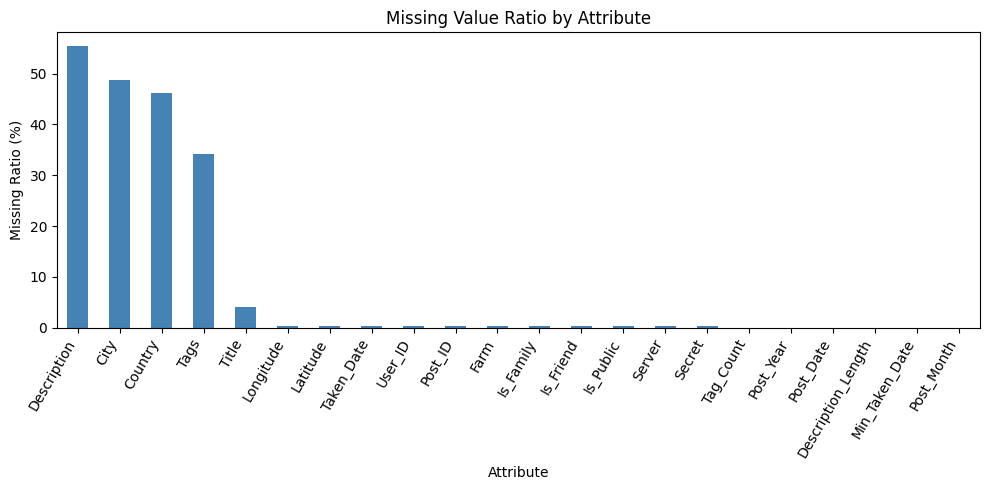

In [58]:
missing_ratio = (eda_df.isna().mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
missing_ratio.plot(kind="bar", color="steelblue")
plt.title("Missing Value Ratio by Attribute")
plt.ylabel("Missing Ratio (%)")
plt.xlabel("Attribute")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

### 2.2 Univariate Analysis

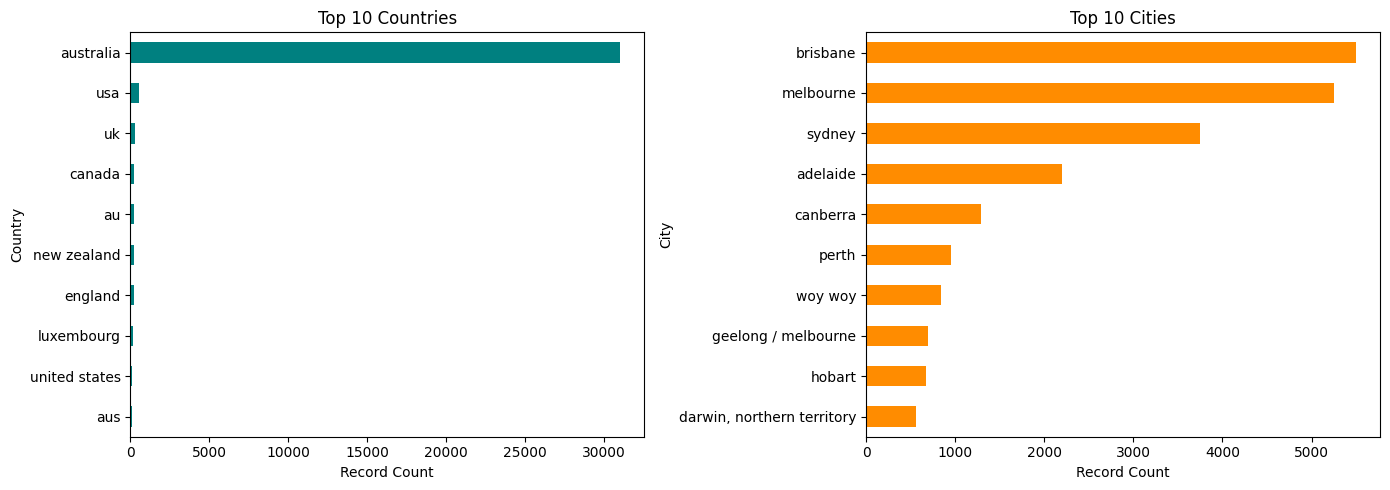

Country
australia        30994
usa                581
uk                 283
canada             265
au                 234
new zealand        219
england            214
luxembourg         160
united states      139
aus                133
Name: count, dtype: int64

City
brisbane                      5493
melbourne                     5251
sydney                        3752
adelaide                      2200
canberra                      1287
perth                          949
woy woy                        845
geelong / melbourne            691
hobart                         672
darwin, northern territory     563
Name: count, dtype: int64

In [59]:
top_countries = eda_df["Country"].dropna().value_counts().head(10)
top_cities = eda_df["City"].dropna().value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_countries.sort_values().plot(kind="barh", ax=axes[0], color="teal")
axes[0].set_title("Top 10 Countries")
axes[0].set_xlabel("Record Count")

top_cities.sort_values().plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("Top 10 Cities")
axes[1].set_xlabel("Record Count")

plt.tight_layout()
plt.show()
display(top_countries)
display(top_cities)

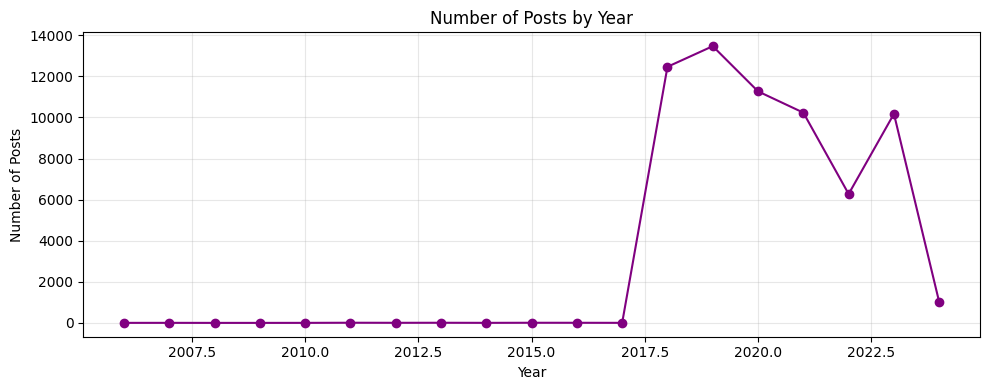

Post_Year
2006        2
2007        3
2008        1
2009        1
2010        2
2011        8
2012        5
2013        7
2014        3
2015        7
2016        6
2017        3
2018    12468
2019    13472
2020    11271
2021    10235
2022     6276
2023    10176
2024     1008
Name: count, dtype: int64

In [60]:
post_year_counts = eda_df["Post_Year"].dropna().astype(int).value_counts().sort_index()

plt.figure(figsize=(10, 4))
post_year_counts.plot(kind="line", marker="o", color="purple")
plt.title("Number of Posts by Year")
plt.xlabel("Year")
plt.ylabel("Number of Posts")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
display(post_year_counts)

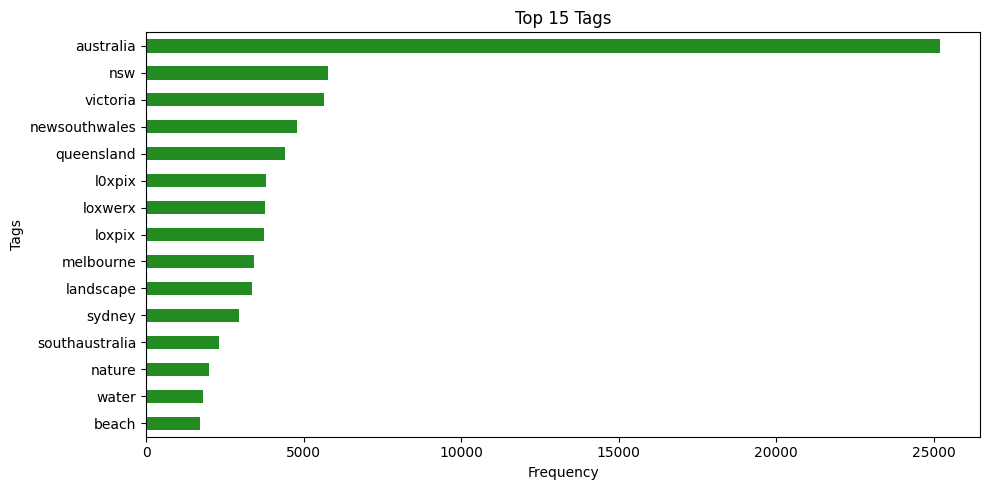

Tags
australia         25215
nsw                5777
victoria           5651
newsouthwales      4779
queensland         4410
l0xpix             3807
loxwerx            3770
loxpix             3761
melbourne          3442
landscape          3351
sydney             2957
southaustralia     2312
nature             1986
water              1812
beach              1724
Name: count, dtype: int64

In [61]:
tag_series = (
    eda_df["Tags"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)
tag_series = tag_series[tag_series.ne("")]
top_tags = tag_series.value_counts().head(15)

plt.figure(figsize=(10, 5))
top_tags.sort_values().plot(kind="barh", color="forestgreen")
plt.title("Top 15 Tags")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()
display(top_tags)

### 2.3 Bivariate Analysis

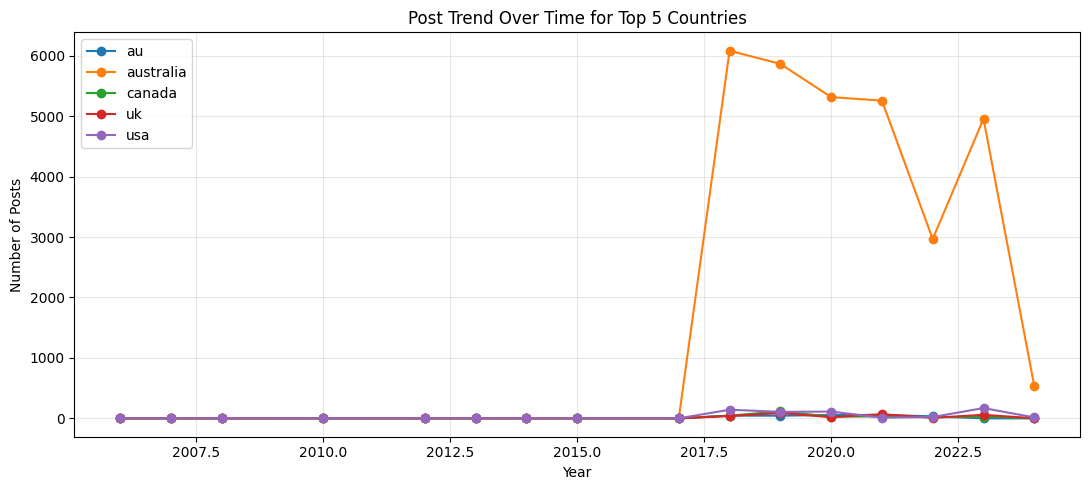

Country,au,australia,canada,uk,usa
Post_Year,,,,,
2006,0,1,0,0,0
2007,0,0,0,0,1
2008,0,1,0,0,0
2010,0,2,0,0,0
2012,0,1,0,0,0
2013,0,2,0,0,0
2014,0,1,0,0,0
2015,0,2,0,0,0
2017,0,1,0,0,0


In [62]:
country_year_df = eda_df.dropna(subset=["Country", "Post_Year"]).copy()
top5_countries = country_year_df["Country"].value_counts().head(5).index.tolist()
country_year_df = country_year_df[country_year_df["Country"].isin(top5_countries)]

country_year_counts = country_year_df.groupby(["Post_Year", "Country"]).size().unstack(fill_value=0).sort_index()

plt.figure(figsize=(11, 5))
for country in country_year_counts.columns:
    plt.plot(country_year_counts.index, country_year_counts[country], marker="o", label=country)
plt.title("Post Trend Over Time for Top 5 Countries")
plt.xlabel("Year")
plt.ylabel("Number of Posts")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
display(country_year_counts)

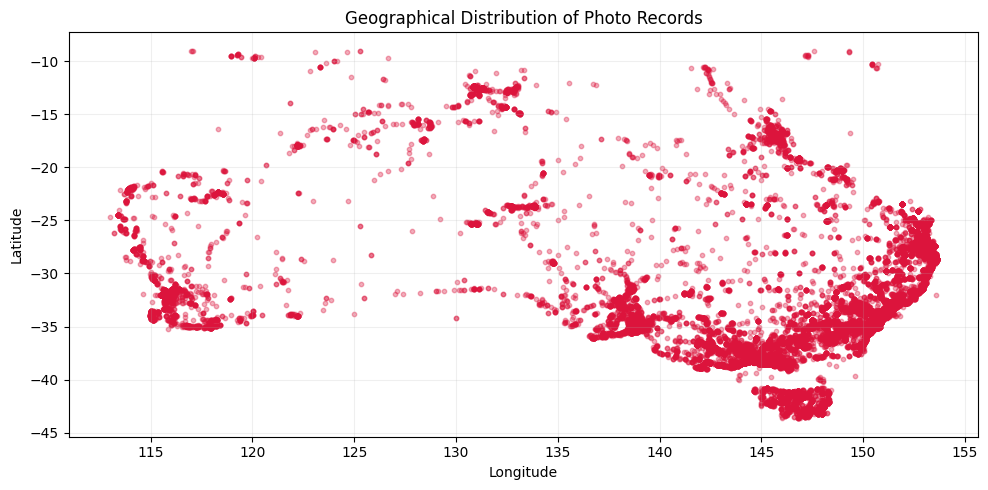

In [63]:
geo_df = eda_df.dropna(subset=["Latitude", "Longitude"]).copy()

plt.figure(figsize=(10, 5))
plt.scatter(geo_df["Longitude"], geo_df["Latitude"], alpha=0.35, s=10, color="crimson")
plt.title("Geographical Distribution of Photo Records")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### 2.4 Multivariate Analysis

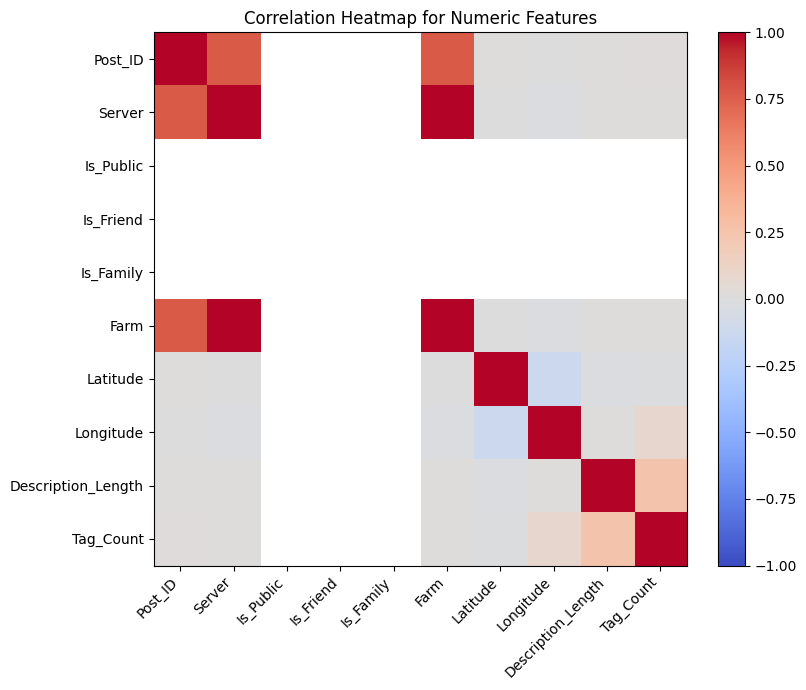

,Post_ID,Server,Is_Public,Is_Friend,Is_Family,Farm,Latitude,Longitude,Description_Length,Tag_Count
Post_ID,1.000,0.773,NaN,NaN,NaN,0.773,0.003,-0.001,0.001,0.009
Server,0.773,1.000,NaN,NaN,NaN,1.000,-0.006,-0.017,0.007,0.004
Is_Public,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Is_Friend,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Is_Family,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm,0.773,1.000,NaN,NaN,NaN,1.000,-0.006,-0.017,0.007,0.004
Latitude,0.003,-0.006,NaN,NaN,NaN,-0.006,1.000,-0.119,-0.022,-0.012
Longitude,-0.001,-0.017,NaN,NaN,NaN,-0.017,-0.119,1.000,0.005,0.080
Description_Length,0.001,0.007,NaN,NaN,NaN,0.007,-0.022,0.005,1.000,0.256
Tag_Count,0.009,0.004,NaN,NaN,NaN,0.004,-0.012,0.080,0.256,1.000


In [64]:
numeric_cols = ["Post_ID", "Server", "Is_Public", "Is_Friend", "Is_Family", "Farm", "Latitude", "Longitude", "Description_Length", "Tag_Count"]
corr = eda_df[numeric_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title("Correlation Heatmap for Numeric Features")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
display(corr.round(3))

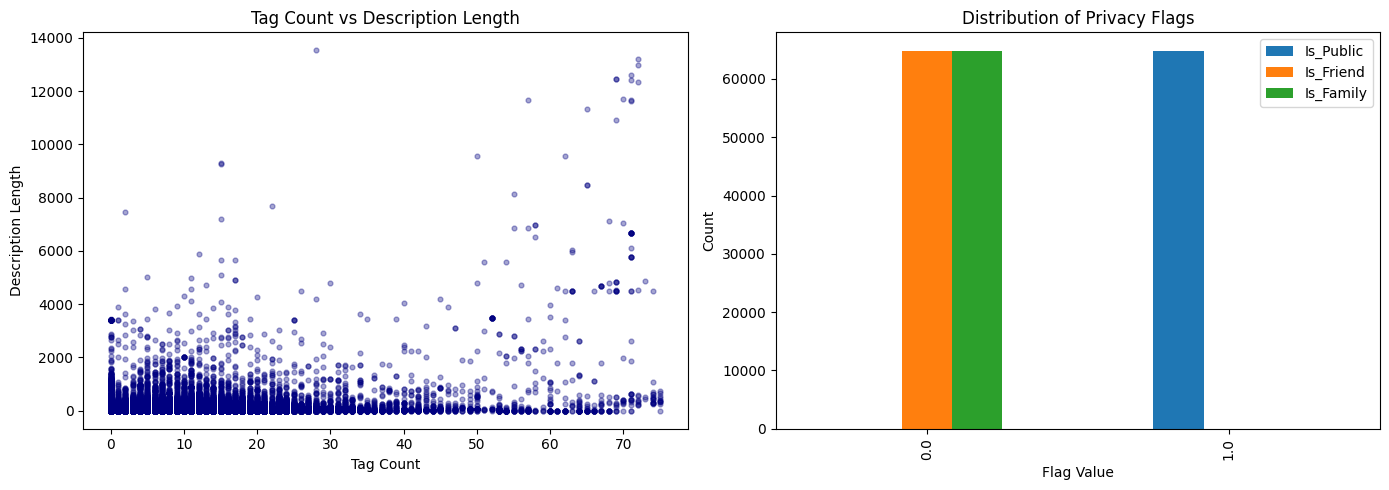

,Is_Public,Is_Friend,Is_Family
0.0,0.0,64758.0,64758.0
1.0,64758.0,0.0,0.0


In [65]:
plot_df = eda_df.dropna(subset=["Description_Length", "Tag_Count"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(plot_df["Tag_Count"], plot_df["Description_Length"], alpha=0.35, s=12, color="navy")
axes[0].set_title("Tag Count vs Description Length")
axes[0].set_xlabel("Tag Count")
axes[0].set_ylabel("Description Length")

privacy_summary = eda_df[["Is_Public", "Is_Friend", "Is_Family"]].apply(pd.Series.value_counts).fillna(0)
privacy_summary.plot(kind="bar", ax=axes[1], color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[1].set_title("Distribution of Privacy Flags")
axes[1].set_xlabel("Flag Value")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()
display(privacy_summary)

## 3. Key Insights and ML Questions

### 3.1 示例 Insights（讲课时可展开成完整英文）

下面这些是结合当前 `GroupXXX` 这组数据跑出来的结果整理出来的方向。正式提交时还是要根据你们自己的图和表来写完整英文说明：

1. 数据在地理上高度集中，`Australia` 占绝对多数，说明数据分布明显偏向澳洲场景，而不是全球均匀分布。
2. 文本和地点字段缺失很严重，例如 `Description` 缺失约 55.37%，`City` 缺失约 48.68%，`Country` 缺失约 46.12%，说明原始 metadata 完整度不均衡。
3. 合并后存在真实的冗余重复记录；本次运行中从 65,986 行去重到 64,954 行，共去掉 1,032 行，说明 deduplication 是必要步骤，不是可选优化。
4. 城市分布集中在 `Brisbane`, `Melbourne`, `Sydney`, `Adelaide`, `Canberra` 等澳洲城市，进一步支持地理集中这一发现。
5. 国家字段存在标准不统一问题，例如 `australia`, `au`, `aus` 同时出现，说明 location standardisation 会是后续建模前的重要 preprocessing 工作。
6. 标签呈明显长尾分布，高频标签如 `australia`, `nsw`, `victoria`, `newsouthwales`, `queensland` 占据大量记录，说明主题高度集中在地点相关内容。
7. 时间分布不均匀，2020 到 2023 年明显更活跃，适合进一步讨论时间趋势、活跃周期和 forecasting 问题。
8. 由于 `Is_Public`, `Is_Friend`, `Is_Family` 大概率方差很低，这类隐私字段对建模的区分能力可能有限。
9. 这个数据集同时有结构化字段、文本字段、时间字段和地理坐标，因此适合分类、聚类、时间序列和数据补全等多类机器学习问题。
10. 由于文本缺失较多但标签相对更稳定，后续建模时 `Tags` 可能比 `Description` 提供更强的主题信息。

### 3.2 示例 ML Questions

#### Q1. 能否根据标题、标签、描述和坐标预测帖子所属国家？
- 类型：监督学习分类
- 输入：`Title`, `Tags`, `Description`, `Latitude`, `Longitude`
- 输出：`Country`
- 为什么适合这组数据：`Country` 缺失接近一半，但 `Tags` 和经纬度包含明显地点信息
- 价值：补全缺失 metadata，提高数据完整性

#### Q2. 能否根据历史发帖数量预测未来某个国家/城市的发帖趋势？
- 类型：时间序列预测 / 回归
- 输入：时间窗口内的历史数量、地点信息、lag features
- 输出：未来发帖数
- 为什么适合这组数据：2020 到 2023 年的发帖量明显更高，存在较清晰的时间变化
- 价值：趋势预测与活跃度监控

#### Q3. 能否根据用户发帖频率、标签偏好、地理分布对用户进行聚类？
- 类型：无监督学习聚类
- 输入：user-level 聚合特征
- 输出：cluster labels
- 为什么适合这组数据：标签和地点分布都很集中，适合构建用户画像特征
- 价值：用户画像与行为分群

#### Q4. 能否用空间和文本特征识别异常帖子或异常热点区域？
- 类型：异常检测
- 输入：坐标、时间、标签数、描述长度等
- 输出：异常分数 / 异常标签
- 为什么适合这组数据：整体热点集中在澳洲主要城市，离群点和异常区域更容易被识别
- 价值：发现异常事件或异常数据

#### Q5. 能否根据其他元数据推断缺失的 `City` 或 `Country`？
- 类型：监督学习 / 半监督学习
- 输入：文本字段、坐标、时间特征、用户特征
- 输出：缺失地点字段
- 为什么适合这组数据：`City` 和 `Country` 缺失比例都很高，是最直接的数据补全场景
- 价值：数据补全，提高后续分析质量

## 4. Tutor 讲解提示

课堂上建议这样讲：

1. 先讲 sample output，再讲代码，不要一上来就画图
2. 强调字段标准化和去重是 2026 版的重要变化
3. 强调 non-Latin 和 non-English 不是一个概念
4. 每张图都要服务于后面的 insight 或 ML question
5. 学生最容易丢分的地方是：字段顺序、清洗规则、ML question 太空泛